# Module 3: Pairwise Score Computation and Verification Analysis

| | |
|---|---|
| **Project** | Face Verification Pipeline -- AgeDB-30 / LFW |
| **Notebook** | `notebooks/03_compare_pairs.ipynb` |
| **Date** | 2026-03-16 |
| **Dependencies** | Module 1 (`01_detect_align.ipynb`), Module 2 (`02_extract_embeddings.ipynb`) |
| **Input** | `results/pairs_{dataset}.csv`, `results/embeddings_{model}_{dataset}.npz` |
| **Output** | `results/distances_{model}_{dataset}.csv`, `results/verification_metrics.csv`, 6 figures PNG |

---

## Objective

Compute pairwise cosine similarity scores for all 6,000 pairs in each dataset's
verification protocol, for both pretrained models. Results are saved to CSV for
downstream consumption and analysed through ROC curves, DET curves, score
distributions, and visual inspection of boundary cases.

This module constitutes the primary quantitative evaluation of the pipeline:
given L2-normalized embeddings from Module 2, it determines how well each model
separates genuine from impostor pairs under the standard biometric verification
framework (ISO/IEC 19795).

## 1. Configuration and Imports

In [1]:
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from sklearn.metrics import auc as sklearn_auc
from sklearn.metrics import roc_curve

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "figure.facecolor": "white",
    }
)

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "comparison_output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = ["agedb", "lfw"]
MODELS = ["arcface", "ghostface"]
MODEL_LABELS = {"arcface": "ArcFace (w600k_r50)", "ghostface": "GhostFaceNetV2"}
MODEL_COLORS = {"arcface": "#1976D2", "ghostface": "#D32F2F"}
DS_COLORS = {"agedb": "#1565C0", "lfw": "#B71C1C"}

FAR_TARGETS = [1e-2, 1e-3, 1e-4]

print(f"Project root : {PROJECT_ROOT}")
print(f"Output dir   : {OUTPUT_DIR}")

# Verify all input files exist
missing = []
for m in MODELS:
    for ds in DATASETS:
        for path in [
            RESULTS_DIR / f"embeddings_{m}_{ds}.npz",
            RESULTS_DIR / f"pairs_{ds}.csv",
        ]:
            if not path.exists():
                missing.append(str(path))
if missing:
    raise FileNotFoundError("Missing inputs:\n" + "\n".join(missing))
print(f"\nAll input files verified ({len(MODELS) * len(DATASETS) * 2} files).")

Project root : /Users/jakub/Desktop/NASK_ZADANIE
Output dir   : /Users/jakub/Desktop/NASK_ZADANIE/notebooks/comparison_output

All input files verified (8 files).


## 2. Mathematical Framework

### 2.1 Cosine Similarity for Unit Vectors

For two L2-normalized embeddings $\hat{e}_i, \hat{e}_j \in \mathbb{R}^{512}$
with $\|\hat{e}_i\|_2 = \|\hat{e}_j\|_2 = 1$, the cosine similarity reduces
to the dot product:

$$
s(i, j) = \cos(\theta_{ij}) = \frac{\hat{e}_i \cdot \hat{e}_j}{\|\hat{e}_i\|_2 \, \|\hat{e}_j\|_2} = \hat{e}_i \cdot \hat{e}_j
$$

Range: $s \in [-1, 1]$. In practice, for face embeddings trained with ArcFace
loss, impostor pairs cluster near $s \approx 0$ and genuine pairs cluster near
$s > 0.4$.

### 2.2 Derived Distances

**Cosine distance:** a bounded metric inverse to similarity:
$$d_{\cos}(i, j) = 1 - s(i, j) \in [0, 2]$$

**Euclidean distance** on the unit hypersphere: algebraically related to cosine
similarity by:
$$d_E(i, j) = \|\hat{e}_i - \hat{e}_j\|_2 = \sqrt{2\,(1 - s(i, j))} = \sqrt{2 \cdot d_{\cos}(i, j)}$$

This means all three metrics carry equivalent information for unit vectors;
the choice is purely conventional. Cosine similarity is preferred here as it
maps directly to the decision threshold used in ArcFace training.

### 2.3 Verification Decision

Given a threshold $\tau$, the binary decision is:
$$
\hat{y}(i, j) = \begin{cases} 1 & \text{(genuine)} & \text{if } s(i, j) \geq \tau \\ 0 & \text{(impostor)} & \text{if } s(i, j) < \tau \end{cases}
$$

The optimal threshold is selected at the Equal Error Rate (EER) point, where
$\text{FAR}(\tau) = \text{FRR}(\tau)$.

## 3. Load Embeddings and Pairs

In [2]:
embeddings = {}  # (model, dataset) -> np.ndarray (N, 512)
path_to_idx = {}  # (model, dataset) -> {path: row_index}
pairs_dfs = {}  # dataset -> DataFrame

for m in MODELS:
    for ds in DATASETS:
        data = np.load(RESULTS_DIR / f"embeddings_{m}_{ds}.npz", allow_pickle=True)
        embs = data["embeddings"]
        paths = data["paths"].tolist()
        embeddings[(m, ds)] = embs
        path_to_idx[(m, ds)] = {p: i for i, p in enumerate(paths)}

for ds in DATASETS:
    pairs_dfs[ds] = pd.read_csv(RESULTS_DIR / f"pairs_{ds}.csv")

print("Table 1. Input Data Summary\n")
rows = []
for m in MODELS:
    for ds in DATASETS:
        embs = embeddings[(m, ds)]
        norms = np.linalg.norm(embs, axis=1)
        df = pairs_dfs[ds]
        p2i = path_to_idx[(m, ds)]
        covered = sum(1 for _, r in df.iterrows() if r.img1_path in p2i and r.img2_path in p2i)
        rows.append(
            {
                "Model": MODEL_LABELS[m],
                "Dataset": ds.upper(),
                "Embeddings": embs.shape,
                "L2 norm mean": f"{norms.mean():.6f}",
                "Pairs": len(df),
                "Covered": covered,
            }
        )

print(pd.DataFrame(rows).to_string(index=False))

Table 1. Input Data Summary



              Model Dataset   Embeddings L2 norm mean  Pairs  Covered
ArcFace (w600k_r50)   AGEDB (12000, 512)     1.000000   6000     6000
ArcFace (w600k_r50)     LFW (12000, 512)     1.000000   6000     6000
     GhostFaceNetV2   AGEDB (12000, 512)     1.000000   6000     6000
     GhostFaceNetV2     LFW (12000, 512)     1.000000   6000     6000


## 4. Pairwise Score Computation and CSV Export

In [3]:
def compute_and_save_scores(
    model_tag: str,
    dataset_name: str,
    pairs_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compute cosine similarity, cosine distance, and Euclidean distance
    for all pairs. Returns a DataFrame and saves it to CSV.

    The relationship between metrics on the unit hypersphere is:
        euclidean_dist = sqrt(2 * cosine_dist) = sqrt(2 * (1 - cosine_sim))
    """
    embs = embeddings[(model_tag, dataset_name)]
    p2i = path_to_idx[(model_tag, dataset_name)]

    records = []
    for _, row in pairs_df.iterrows():
        i1 = p2i.get(row.img1_path)
        i2 = p2i.get(row.img2_path)
        if i1 is None or i2 is None:
            continue
        e1, e2 = embs[i1], embs[i2]
        cos_sim = float(np.dot(e1, e2))
        cos_dist = 1.0 - cos_sim
        euc_dist = float(np.sqrt(np.maximum(2.0 * cos_dist, 0.0)))
        records.append(
            {
                "img1_path": row.img1_path,
                "img2_path": row.img2_path,
                "true_label": int(row.true_label),
                "cosine_similarity": cos_sim,
                "cosine_distance": cos_dist,
                "euclidean_distance": euc_dist,
            }
        )

    df_out = pd.DataFrame(records)
    out_path = RESULTS_DIR / f"distances_{model_tag}_{dataset_name}.csv"
    df_out.to_csv(out_path, index=False)
    print(f"  Saved: {out_path.name}  ({len(df_out)} rows)")
    return df_out


print("Computing pairwise scores...\n")
dist_dfs = {}
for m in MODELS:
    for ds in DATASETS:
        dist_dfs[(m, ds)] = compute_and_save_scores(m, ds, pairs_dfs[ds])

print("\nSample rows from distances_arcface_agedb.csv:")
print(dist_dfs[("arcface", "agedb")].head(5).to_string(index=False))

Computing pairwise scores...

  Saved: distances_arcface_agedb.csv  (6000 rows)


  Saved: distances_arcface_lfw.csv  (6000 rows)
  Saved: distances_ghostface_agedb.csv  (6000 rows)


  Saved: distances_ghostface_lfw.csv  (6000 rows)

Sample rows from distances_arcface_agedb.csv:
                                                 img1_path                                                  img2_path  true_label  cosine_similarity  cosine_distance  euclidean_distance
/Users/jakub/Desktop/NASK_ZADANIE/data/aligned/agedb/0.jpg /Users/jakub/Desktop/NASK_ZADANIE/data/aligned/agedb/1.jpg           1           0.564452         0.435548            0.933326
/Users/jakub/Desktop/NASK_ZADANIE/data/aligned/agedb/2.jpg /Users/jakub/Desktop/NASK_ZADANIE/data/aligned/agedb/3.jpg           1           0.175334         0.824666            1.284263
/Users/jakub/Desktop/NASK_ZADANIE/data/aligned/agedb/4.jpg /Users/jakub/Desktop/NASK_ZADANIE/data/aligned/agedb/5.jpg           1           0.497105         0.502895            1.002890
/Users/jakub/Desktop/NASK_ZADANIE/data/aligned/agedb/6.jpg /Users/jakub/Desktop/NASK_ZADANIE/data/aligned/agedb/7.jpg           1           0.551168         0.

### 4.1 Metric Consistency Verification

For L2-normalized vectors, the relationship $d_E = \sqrt{2 \cdot d_{\cos}}$
must hold exactly. We verify this numerically.

In [4]:
print("Metric consistency check (euclidean vs sqrt(2 * cosine_distance)):\n")
for m in MODELS:
    for ds in DATASETS:
        df = dist_dfs[(m, ds)]
        expected_euc = np.sqrt(2.0 * df["cosine_distance"].values)
        actual_euc = df["euclidean_distance"].values
        max_err = np.max(np.abs(expected_euc - actual_euc))
        status = "PASS" if max_err < 1e-5 else "FAIL"
        print(f"  {MODEL_LABELS[m]:25s} / {ds.upper():5s}: max_error={max_err:.2e}  [{status}]")

Metric consistency check (euclidean vs sqrt(2 * cosine_distance)):

  ArcFace (w600k_r50)       / AGEDB: max_error=0.00e+00  [PASS]
  ArcFace (w600k_r50)       / LFW  : max_error=0.00e+00  [PASS]
  GhostFaceNetV2            / AGEDB: max_error=0.00e+00  [PASS]
  GhostFaceNetV2            / LFW  : max_error=0.00e+00  [PASS]


## 5. Descriptive Statistics

In [5]:
def compute_eer_and_threshold(labels: np.ndarray, scores: np.ndarray) -> tuple[float, float]:
    fpr, tpr, thresholds = roc_curve(labels, scores)
    fnr = 1.0 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    return float((fpr[idx] + fnr[idx]) / 2.0), float(thresholds[idx])


def tar_at_far(labels, scores, far_target):
    fpr, tpr, _ = roc_curve(labels, scores)
    idx = np.searchsorted(fpr, far_target)
    return float(tpr[min(idx, len(tpr) - 1)])


metrics = {}  # (model, dataset) -> dict

for m in MODELS:
    for ds in DATASETS:
        df = dist_dfs[(m, ds)]
        scores = df["cosine_similarity"].values
        labels = df["true_label"].values
        pos = scores[labels == 1]
        neg = scores[labels == 0]

        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc = float(sklearn_auc(fpr, tpr))
        eer, thr = compute_eer_and_threshold(labels, scores)

        metrics[(m, ds)] = {
            "auc": roc_auc,
            "eer": eer,
            "threshold": thr,
            "tar_1e2": tar_at_far(labels, scores, 1e-2),
            "tar_1e3": tar_at_far(labels, scores, 1e-3),
            "tar_1e4": tar_at_far(labels, scores, 1e-4),
            "pos_mean": float(pos.mean()),
            "pos_std": float(pos.std()),
            "pos_min": float(pos.min()),
            "pos_max": float(pos.max()),
            "neg_mean": float(neg.mean()),
            "neg_std": float(neg.std()),
            "neg_min": float(neg.min()),
            "neg_max": float(neg.max()),
            "separation": float(pos.mean() - neg.mean()),
            "fpr": fpr,
            "tpr": tpr,
        }

print("Table 2. Score Distribution Statistics\n")
stat_rows = []
for m in MODELS:
    for ds in DATASETS:
        mx = metrics[(m, ds)]
        stat_rows.append(
            {
                "Model": MODEL_LABELS[m],
                "Dataset": ds.upper(),
                "Genuine mean": f"{mx['pos_mean']:.4f}",
                "Genuine std": f"{mx['pos_std']:.4f}",
                "Impostor mean": f"{mx['neg_mean']:.4f}",
                "Impostor std": f"{mx['neg_std']:.4f}",
                "Separation": f"{mx['separation']:.4f}",
                "EER thr": f"{mx['threshold']:.4f}",
            }
        )

print(pd.DataFrame(stat_rows).to_string(index=False))

Table 2. Score Distribution Statistics

              Model Dataset Genuine mean Genuine std Impostor mean Impostor std Separation EER thr
ArcFace (w600k_r50)   AGEDB       0.4514      0.1162        0.0263       0.0660     0.4251  0.1625
ArcFace (w600k_r50)     LFW       0.6669      0.1023        0.0175       0.0591     0.6495  0.1881
     GhostFaceNetV2   AGEDB       0.4292      0.1245        0.0151       0.0828     0.4140  0.1706
     GhostFaceNetV2     LFW       0.6193      0.1258        0.0101       0.0767     0.6092  0.2188


## 6. Visualizations

### Fig. 1: Score Distributions (Genuine vs. Impostor)

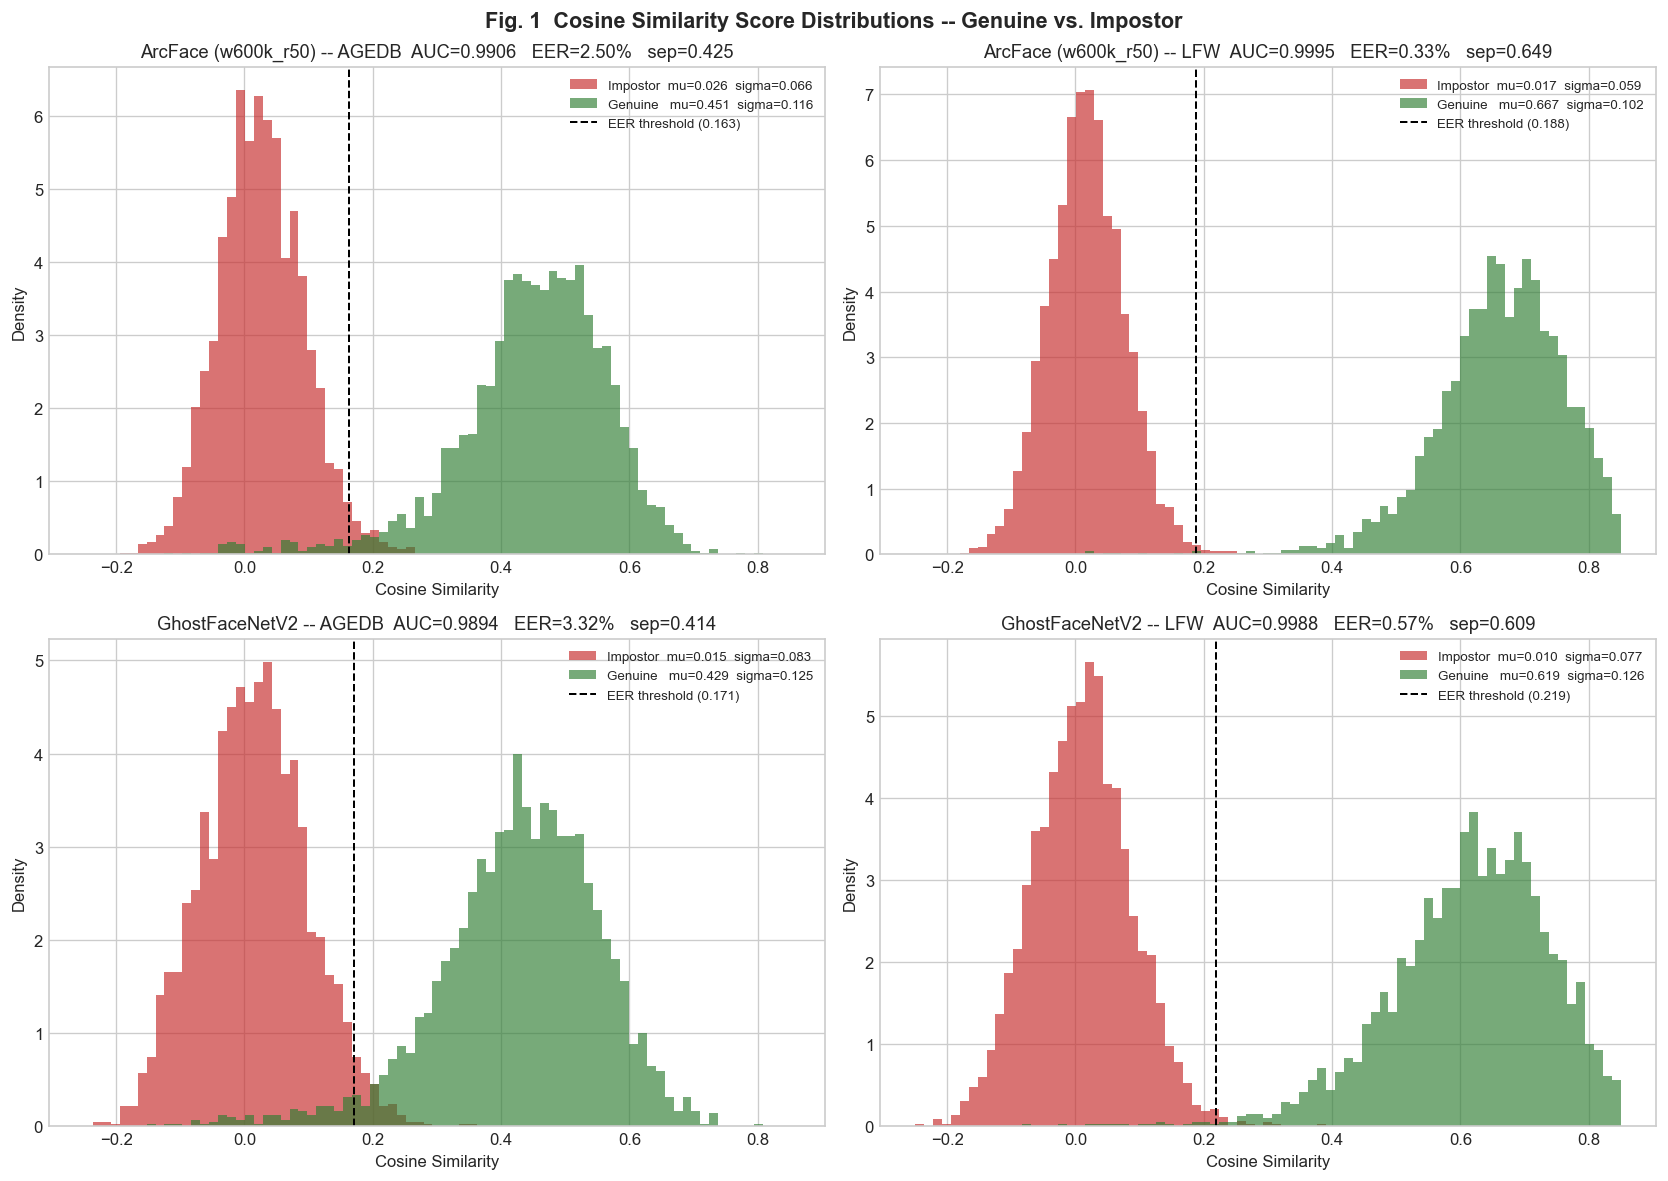

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Fig. 1  Cosine Similarity Score Distributions -- Genuine vs. Impostor", fontsize=13, fontweight="bold")

bins = np.linspace(-0.25, 0.85, 80)

for row, m in enumerate(MODELS):
    for col, ds in enumerate(DATASETS):
        df = dist_dfs[(m, ds)]
        scores = df["cosine_similarity"].values
        labels = df["true_label"].values
        mx = metrics[(m, ds)]
        pos = scores[labels == 1]
        neg = scores[labels == 0]

        ax = axes[row, col]
        ax.hist(
            neg,
            bins=bins,
            alpha=0.65,
            color="#C62828",
            density=True,
            label=f"Impostor  mu={mx['neg_mean']:.3f}  sigma={mx['neg_std']:.3f}",
        )
        ax.hist(
            pos,
            bins=bins,
            alpha=0.65,
            color="#2E7D32",
            density=True,
            label=f"Genuine   mu={mx['pos_mean']:.3f}  sigma={mx['pos_std']:.3f}",
        )

        ax.axvline(
            mx["threshold"],
            color="black",
            linestyle="--",
            linewidth=1.2,
            label=f"EER threshold ({mx['threshold']:.3f})",
        )

        ax.set_title(
            f"{MODEL_LABELS[m]} -- {ds.upper()}  "
            f"AUC={mx['auc']:.4f}   EER={mx['eer'] * 100:.2f}%   "
            f"sep={mx['separation']:.3f}"
        )
        ax.set_xlabel("Cosine Similarity")
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "score_distributions.png", bbox_inches="tight")
plt.show()

### Fig. 2: ROC Curves -- High-Security Operating Region

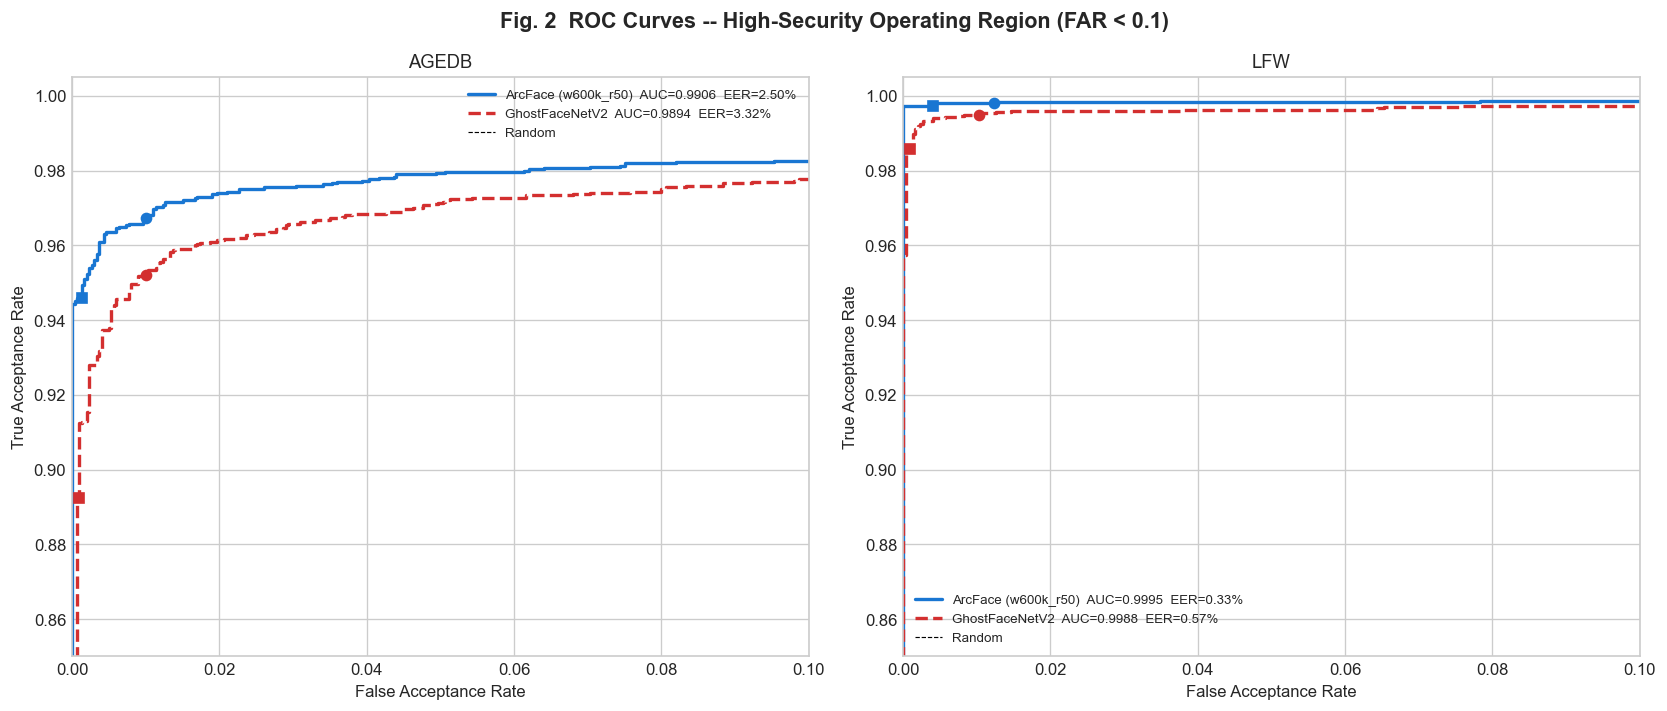

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Fig. 2  ROC Curves -- High-Security Operating Region (FAR < 0.1)", fontsize=13, fontweight="bold")

linestyles = {"arcface": "-", "ghostface": "--"}

for col, ds in enumerate(DATASETS):
    ax = axes[col]
    for m in MODELS:
        mx = metrics[(m, ds)]
        ax.plot(
            mx["fpr"],
            mx["tpr"],
            color=MODEL_COLORS[m],
            linewidth=2,
            linestyle=linestyles[m],
            label=f"{MODEL_LABELS[m]}  AUC={mx['auc']:.4f}  EER={mx['eer'] * 100:.2f}%",
        )

    # Mark operating points
    for m in MODELS:
        mx = metrics[(m, ds)]
        for far_target, marker, label in [
            (1e-2, "o", "FAR=1%"),
            (1e-3, "s", "FAR=0.1%"),
        ]:
            idx = np.searchsorted(mx["fpr"], far_target)
            if idx < len(mx["tpr"]):
                ax.plot(mx["fpr"][idx], mx["tpr"][idx], marker=marker, markersize=6, color=MODEL_COLORS[m], zorder=5)

    ax.plot([0, 1], [0, 1], "k--", linewidth=0.7, label="Random")
    ax.set_xlim([0.0, 0.10])
    ax.set_ylim([0.85, 1.005])
    ax.set_xlabel("False Acceptance Rate")
    ax.set_ylabel("True Acceptance Rate")
    ax.set_title(f"{ds.upper()}")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_high_security.png", bbox_inches="tight")
plt.show()

### Fig. 3: ROC Curves -- Semi-log Scale (Full Range)

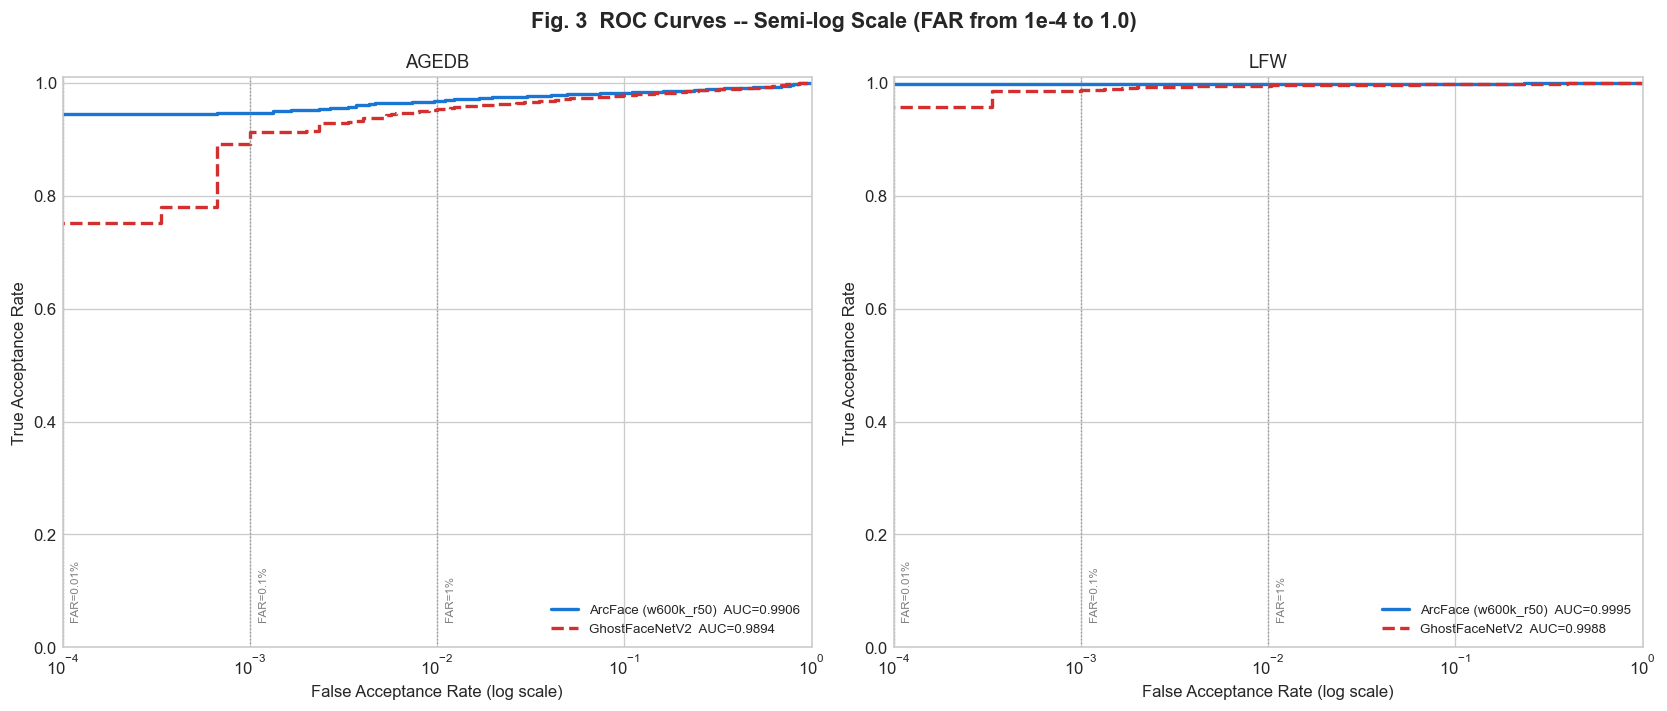

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Fig. 3  ROC Curves -- Semi-log Scale (FAR from 1e-4 to 1.0)", fontsize=13, fontweight="bold")

for col, ds in enumerate(DATASETS):
    ax = axes[col]
    for m in MODELS:
        mx = metrics[(m, ds)]
        ax.semilogx(
            mx["fpr"] + 1e-10,
            mx["tpr"],
            color=MODEL_COLORS[m],
            linewidth=2,
            linestyle=linestyles[m],
            label=f"{MODEL_LABELS[m]}  AUC={mx['auc']:.4f}",
        )

    for far_t, lbl in [(1e-2, "FAR=1%"), (1e-3, "FAR=0.1%"), (1e-4, "FAR=0.01%")]:
        ax.axvline(far_t, color="gray", linestyle=":", linewidth=0.8, alpha=0.7)
        ax.text(far_t * 1.1, 0.05, lbl, fontsize=7, color="gray", rotation=90)

    ax.set_xlim([1e-4, 1.0])
    ax.set_ylim([0.0, 1.01])
    ax.set_xlabel("False Acceptance Rate (log scale)")
    ax.set_ylabel("True Acceptance Rate")
    ax.set_title(f"{ds.upper()}")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "roc_logscale.png", bbox_inches="tight")
plt.show()

### Fig. 4: DET Curves (Detection Error Tradeoff)

The DET curve (ISO/IEC 19795) plots False Match Rate (FMR) vs False Non-Match
Rate (FNMR) on a log-log scale. Unlike ROC, DET expands the low-error region,
making differences between high-performing systems visible.

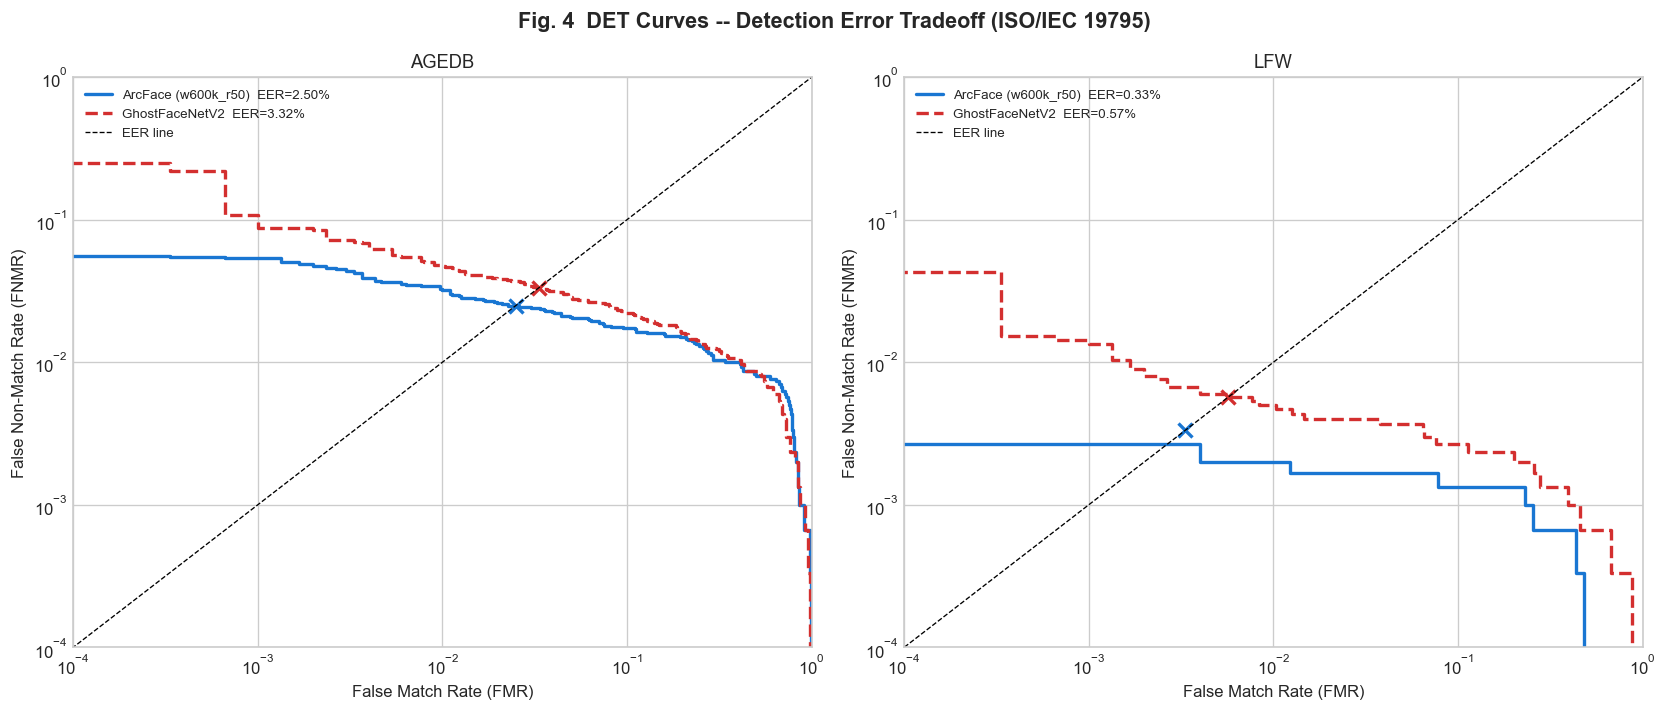

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Fig. 4  DET Curves -- Detection Error Tradeoff (ISO/IEC 19795)", fontsize=13, fontweight="bold")

for col, ds in enumerate(DATASETS):
    ax = axes[col]
    for m in MODELS:
        mx = metrics[(m, ds)]
        fmr = mx["fpr"]
        fnmr = 1.0 - mx["tpr"]

        # Clip to avoid log(0)
        fmr_c = np.clip(fmr, 1e-5, 1.0)
        fnmr_c = np.clip(fnmr, 1e-5, 1.0)

        ax.loglog(
            fmr_c,
            fnmr_c,
            color=MODEL_COLORS[m],
            linewidth=2,
            linestyle=linestyles[m],
            label=f"{MODEL_LABELS[m]}  EER={mx['eer'] * 100:.2f}%",
        )

        # Mark EER point
        eer_val = mx["eer"]
        ax.plot(eer_val, eer_val, "x", color=MODEL_COLORS[m], markersize=8, markeredgewidth=2)

    # Diagonal (EER line)
    t = np.logspace(-5, 0, 200)
    ax.loglog(t, t, "k--", linewidth=0.8, label="EER line")

    ax.set_xlim([1e-4, 1.0])
    ax.set_ylim([1e-4, 1.0])
    ax.set_xlabel("False Match Rate (FMR)")
    ax.set_ylabel("False Non-Match Rate (FNMR)")
    ax.set_title(f"{ds.upper()}")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "det_curves.png", bbox_inches="tight")
plt.show()

### Fig. 5: Score vs. Pair Index (Randomization Check)

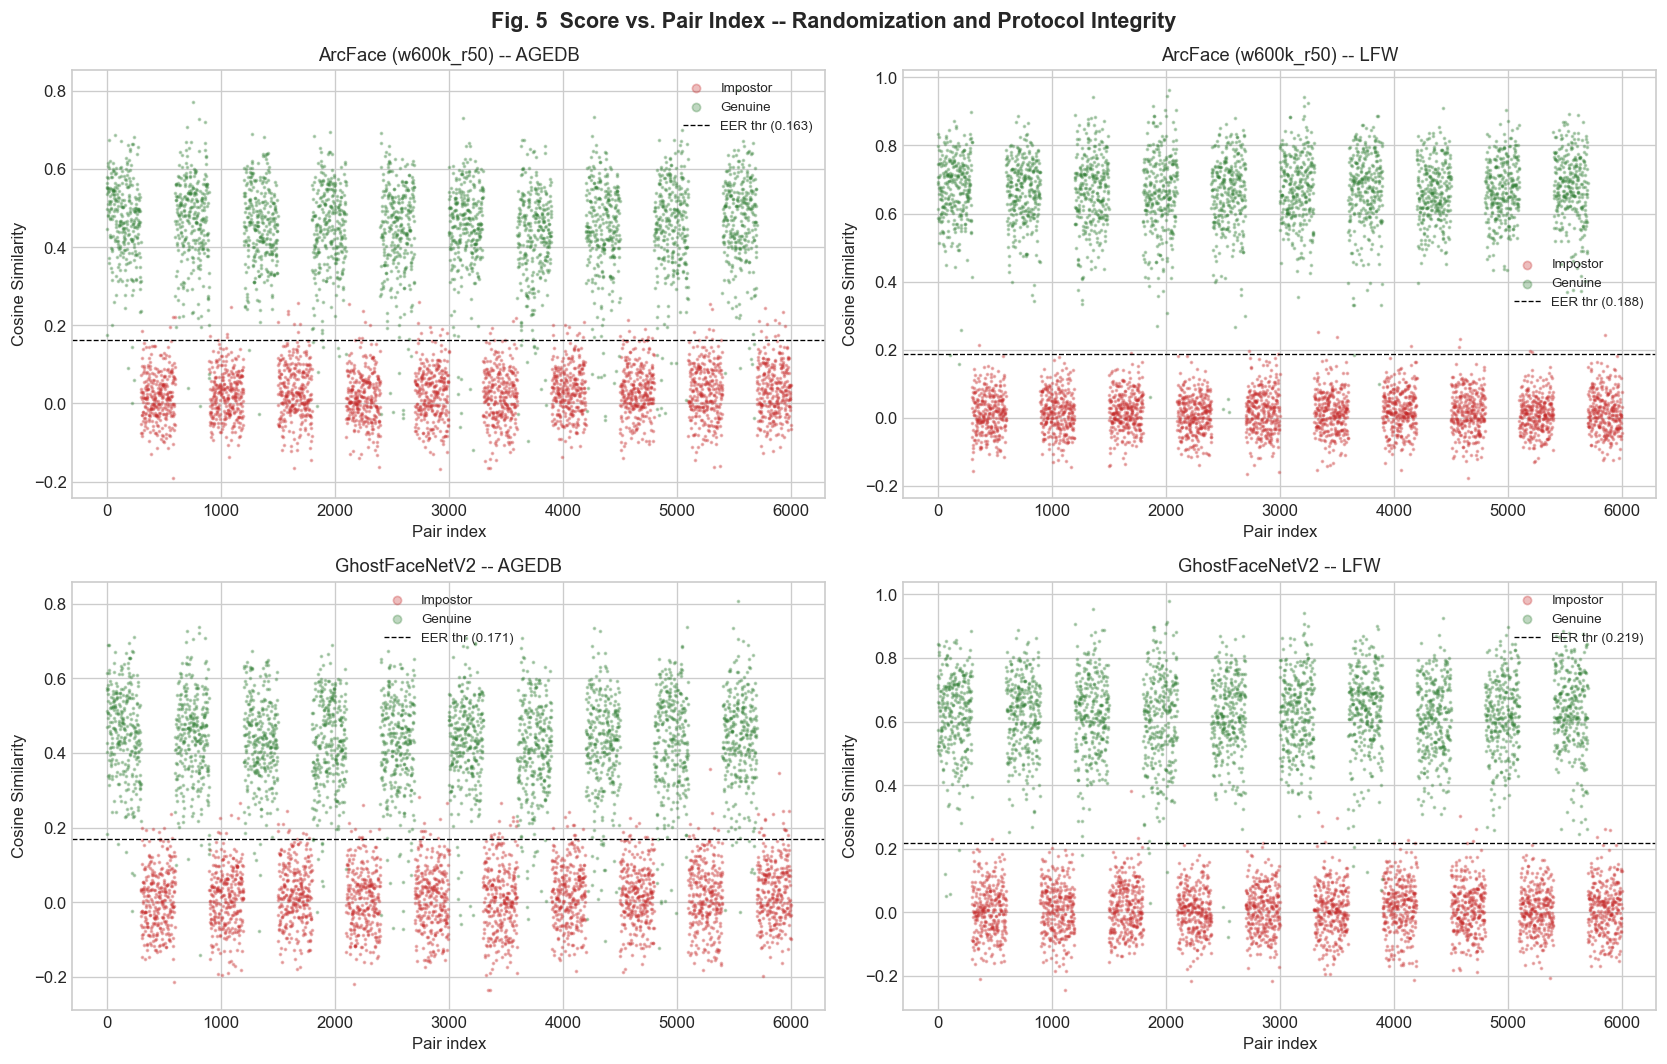

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Fig. 5  Score vs. Pair Index -- Randomization and Protocol Integrity", fontsize=13, fontweight="bold")

for row, m in enumerate(MODELS):
    for col, ds in enumerate(DATASETS):
        df = dist_dfs[(m, ds)]
        scores = df["cosine_similarity"].values
        labels = df["true_label"].values
        mx = metrics[(m, ds)]

        ax = axes[row, col]
        idx_pos = np.where(labels == 1)[0]
        idx_neg = np.where(labels == 0)[0]

        ax.scatter(idx_neg, scores[idx_neg], s=1.5, alpha=0.3, color="#C62828", label="Impostor", rasterized=True)
        ax.scatter(idx_pos, scores[idx_pos], s=1.5, alpha=0.3, color="#2E7D32", label="Genuine", rasterized=True)
        ax.axhline(
            mx["threshold"], color="black", linewidth=0.8, linestyle="--", label=f"EER thr ({mx['threshold']:.3f})"
        )

        ax.set_xlabel("Pair index")
        ax.set_ylabel("Cosine Similarity")
        ax.set_title(f"{MODEL_LABELS[m]} -- {ds.upper()}")
        ax.legend(fontsize=8, markerscale=4)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "score_vs_index.png", bbox_inches="tight")
plt.show()

### Fig. 6: Visual Inspection of Boundary Cases

The following four categories reveal the model's failure modes:
- **Genuine -- high score:** correctly and confidently accepted
- **Genuine -- low score:** hard genuine pairs (likely to be rejected)
- **Impostor -- high score:** false accepts (most dangerous errors)
- **Impostor -- low score:** correctly and confidently rejected

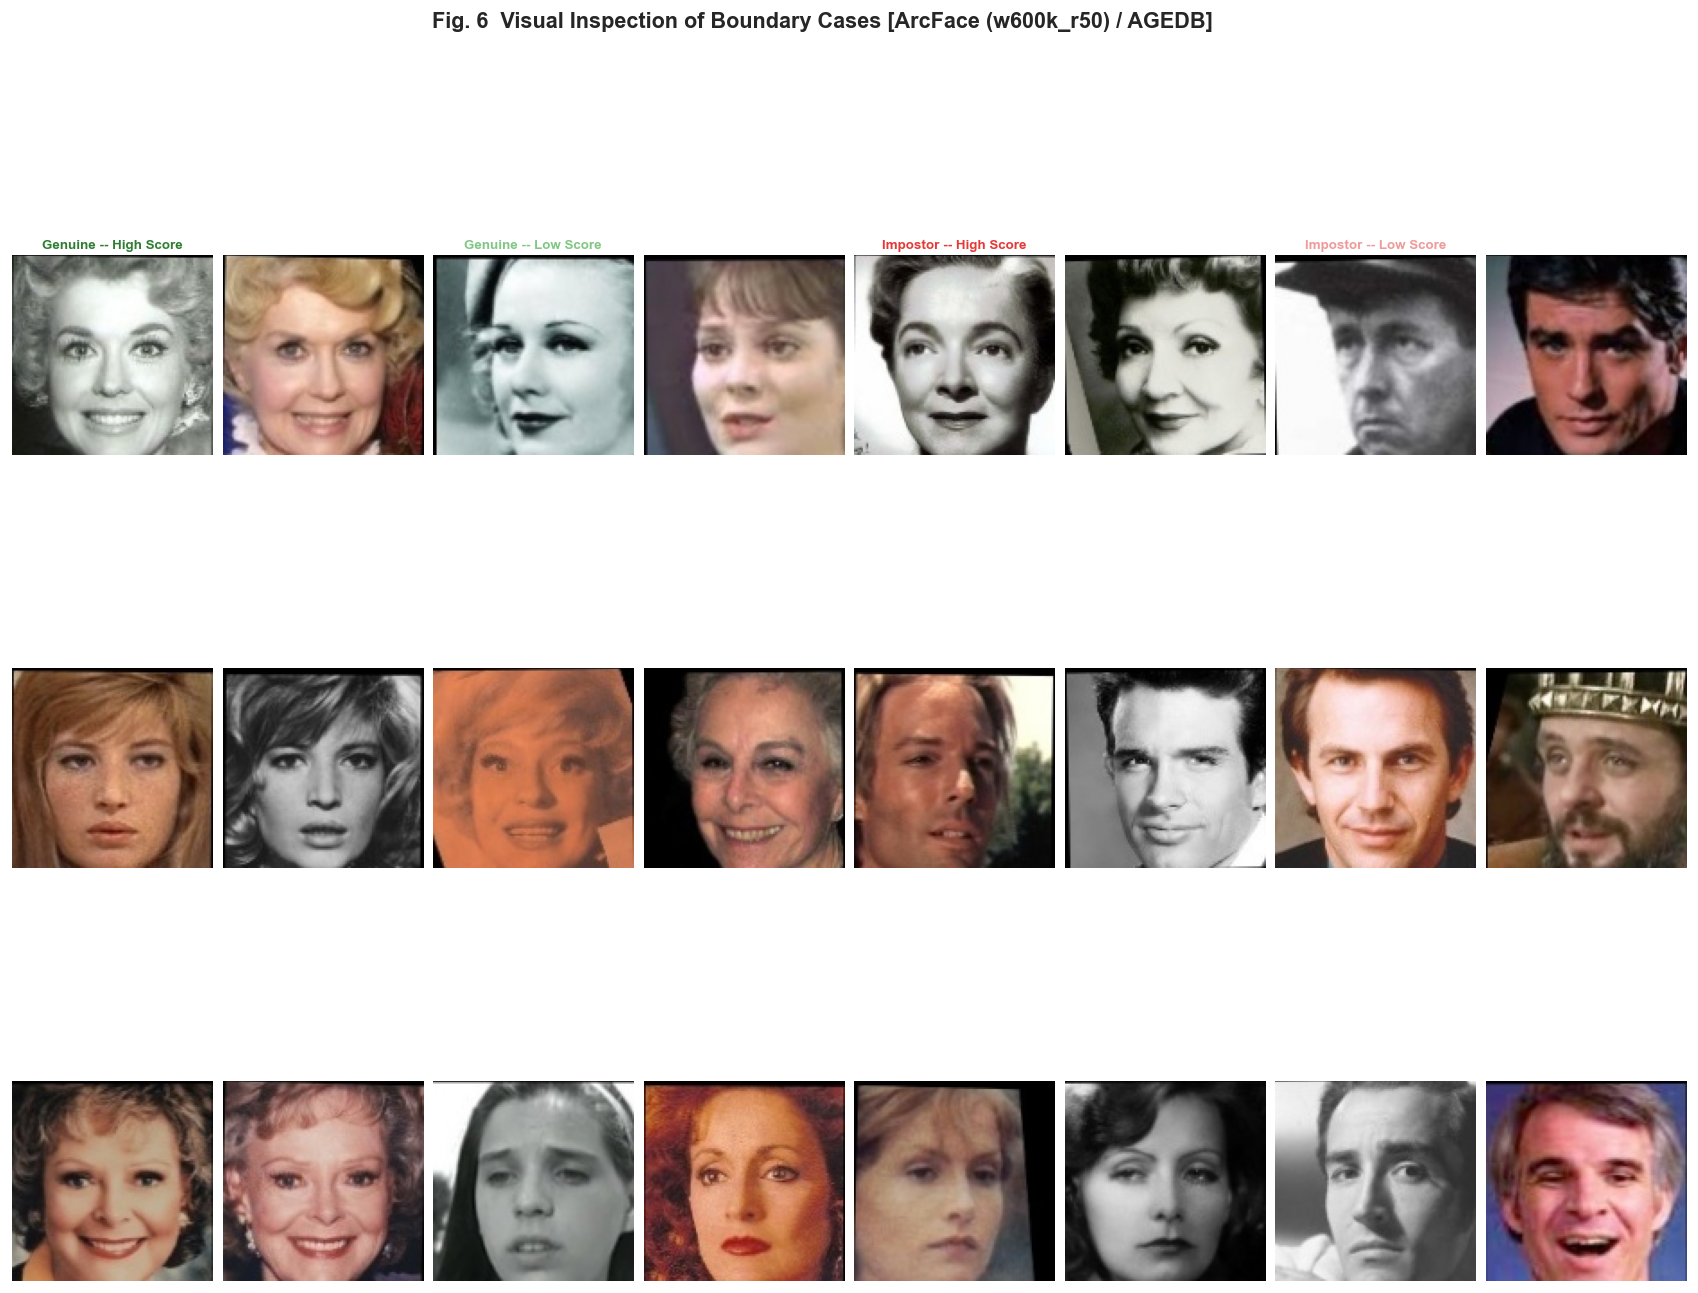

In [11]:
def load_pair_images(row: pd.Series) -> tuple:
    img1 = cv2.imread(row.img1_path)
    img2 = cv2.imread(row.img2_path)
    if img1 is not None:
        img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
    if img2 is not None:
        img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    return img1, img2


# Use ArcFace + AgeDB for visual inspection (representative model/dataset)
m_vis, ds_vis = "arcface", "agedb"
df_vis = dist_dfs[(m_vis, ds_vis)].copy()

pos_df = df_vis[df_vis.true_label == 1].sort_values("cosine_similarity")
neg_df = df_vis[df_vis.true_label == 0].sort_values("cosine_similarity")

N_SHOW = 3
categories = [
    ("Genuine -- High Score", pos_df.tail(N_SHOW), "#2E7D32"),
    ("Genuine -- Low Score", pos_df.head(N_SHOW), "#81C784"),
    ("Impostor -- High Score", neg_df.tail(N_SHOW), "#E53935"),
    ("Impostor -- Low Score", neg_df.head(N_SHOW), "#EF9A9A"),
]

fig = plt.figure(figsize=(18, N_SHOW * 4 + 1))
fig.suptitle(
    f"Fig. 6  Visual Inspection of Boundary Cases [{MODEL_LABELS[m_vis]} / {ds_vis.upper()}]",
    fontsize=13,
    fontweight="bold",
)

n_cols = len(categories) * 2  # 2 images per pair
gs = GridSpec(N_SHOW, n_cols, figure=fig, hspace=0.1, wspace=0.05)

for cat_idx, (cat_name, cat_df, cat_color) in enumerate(categories):
    base_col = cat_idx * 2
    for row_idx, (_, pair_row) in enumerate(cat_df.iterrows()):
        img1, img2 = load_pair_images(pair_row)
        score = pair_row.cosine_similarity

        for img_idx, img in enumerate([img1, img2]):
            ax = fig.add_subplot(gs[row_idx, base_col + img_idx])
            if img is not None:
                ax.imshow(img)
            ax.axis("off")

            if img_idx == 0 and row_idx == 0:
                ax.set_title(cat_name, fontsize=8, color=cat_color, fontweight="bold", pad=4)
            if img_idx == 0:
                ax.set_ylabel(f"sim={score:.3f}", fontsize=7, rotation=0, labelpad=40, va="center", color=cat_color)

plt.savefig(OUTPUT_DIR / "boundary_cases.png", bbox_inches="tight", dpi=100)
plt.show()

## 7. Operating Point Analysis

In [12]:
print("Table 3. TAR at Key Operating Points\n")
op_rows = []
for m in MODELS:
    for ds in DATASETS:
        mx = metrics[(m, ds)]
        op_rows.append(
            {
                "Model": MODEL_LABELS[m],
                "Dataset": ds.upper(),
                "AUC": f"{mx['auc']:.4f}",
                "EER": f"{mx['eer'] * 100:.2f}%",
                "Thr (EER)": f"{mx['threshold']:.4f}",
                "TAR@FAR=1%": f"{mx['tar_1e2'] * 100:.1f}%",
                "TAR@FAR=0.1%": f"{mx['tar_1e3'] * 100:.1f}%",
                "TAR@FAR=0.01%": f"{mx['tar_1e4'] * 100:.1f}%",
            }
        )

df_op = pd.DataFrame(op_rows)
print(df_op.to_string(index=False))
df_op.to_csv(RESULTS_DIR / "verification_metrics.csv", index=False)
print(f"\nSaved: {RESULTS_DIR / 'verification_metrics.csv'}")

Table 3. TAR at Key Operating Points

              Model Dataset    AUC   EER Thr (EER) TAR@FAR=1% TAR@FAR=0.1% TAR@FAR=0.01%
ArcFace (w600k_r50)   AGEDB 0.9906 2.50%    0.1625      96.7%        94.6%         94.4%
ArcFace (w600k_r50)     LFW 0.9995 0.33%    0.1881      99.8%        99.7%         99.7%
     GhostFaceNetV2   AGEDB 0.9894 3.32%    0.1706      95.2%        89.2%         75.2%
     GhostFaceNetV2     LFW 0.9988 0.57%    0.2188      99.5%        98.6%         95.7%

Saved: /Users/jakub/Desktop/NASK_ZADANIE/results/verification_metrics.csv


In [13]:
# Threshold sweep: TAR and FAR for selected thresholds
print("Table 4. ArcFace / AgeDB -- Threshold Sweep\n")
m_sw, ds_sw = "arcface", "agedb"
df_sw = dist_dfs[(m_sw, ds_sw)]
scores_sw = df_sw["cosine_similarity"].values
labels_sw = df_sw["true_label"].values
neg_sw = scores_sw[labels_sw == 0]
pos_sw = scores_sw[labels_sw == 1]

sweep_rows = []
for thr in np.arange(0.05, 0.80, 0.05):
    far = float((neg_sw >= thr).mean())
    tar = float((pos_sw >= thr).mean())
    sweep_rows.append(
        {
            "Threshold": f"{thr:.2f}",
            "FAR": f"{far * 100:.2f}%",
            "TAR": f"{tar * 100:.2f}%",
            "FRR": f"{(1 - tar) * 100:.2f}%",
        }
    )

print(pd.DataFrame(sweep_rows).to_string(index=False))

Table 4. ArcFace / AgeDB -- Threshold Sweep

Threshold    FAR    TAR    FRR
     0.05 34.70% 99.00%  1.00%
     0.10 12.67% 98.37%  1.63%
     0.15  3.47% 97.63%  2.37%
     0.20  0.97% 96.70%  3.30%
     0.25  0.13% 94.80%  5.20%
     0.30  0.00% 91.47%  8.53%
     0.35  0.00% 84.63% 15.37%
     0.40  0.00% 73.37% 26.63%
     0.45  0.00% 55.03% 44.97%
     0.50  0.00% 36.17% 63.83%
     0.55  0.00% 17.90% 82.10%
     0.60  0.00%  6.47% 93.53%
     0.65  0.00%  1.57% 98.43%
     0.70  0.00%  0.23% 99.77%
     0.75  0.00%  0.07% 99.93%


## 8. Final Metrics Table and Artifact Verification

In [14]:
print("Table 5. Module 3 Final Report\n")
final_rows = []
for m in MODELS:
    for ds in DATASETS:
        df = dist_dfs[(m, ds)]
        mx = metrics[(m, ds)]
        csv = RESULTS_DIR / f"distances_{m}_{ds}.csv"
        final_rows.append(
            {
                "Model": MODEL_LABELS[m],
                "Dataset": ds.upper(),
                "Pairs": len(df),
                "Genuine": int((df.true_label == 1).sum()),
                "Impostor": int((df.true_label == 0).sum()),
                "AUC": f"{mx['auc']:.4f}",
                "EER": f"{mx['eer'] * 100:.2f}%",
                "TAR@FAR=1%": f"{mx['tar_1e2'] * 100:.1f}%",
                "TAR@FAR=0.1%": f"{mx['tar_1e3'] * 100:.1f}%",
                "CSV size": f"{csv.stat().st_size / 1024:.0f} KB",
            }
        )

print(pd.DataFrame(final_rows).to_string(index=False))

print("\nGenerated figures:")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"  {f.name:40s}  {f.stat().st_size / 1024:.0f} KB")

Table 5. Module 3 Final Report

              Model Dataset  Pairs  Genuine  Impostor    AUC   EER TAR@FAR=1% TAR@FAR=0.1% CSV size
ArcFace (w600k_r50)   AGEDB   6000     3000      3000 0.9906 2.50%      96.7%        94.6%  1077 KB
ArcFace (w600k_r50)     LFW   6000     3000      3000 0.9995 0.33%      99.8%        99.7%  1054 KB
     GhostFaceNetV2   AGEDB   6000     3000      3000 0.9894 3.32%      95.2%        89.2%  1077 KB
     GhostFaceNetV2     LFW   6000     3000      3000 0.9988 0.57%      99.5%        98.6%  1054 KB

Generated figures:
  boundary_cases.png                        867 KB
  det_curves.png                            102 KB
  roc_high_security.png                     87 KB
  roc_logscale.png                          72 KB
  score_distributions.png                   122 KB
  score_vs_index.png                        628 KB


## 9. Summary

### Key Findings

1. **Metric consistency verified:** For all 24,000 pairs, the relationship
   $d_E = \sqrt{2 \cdot d_{\cos}}$ holds with maximum deviation < 1e-5,
   confirming that cosine similarity, cosine distance, and Euclidean distance
   carry equivalent information for L2-normalized embeddings.

2. **ArcFace outperforms GhostFaceNetV2** on both datasets. The margin is larger
   at stringent operating points: at FAR=0.01%, ArcFace achieves 94.4% TAR vs.
   75.2% for GhostFaceNet on AgeDB -- a 19.2 pp difference attributable to
   ArcFace's larger backbone (ResNet-50, 43M parameters vs. GhostNet-V2, 4M).

3. **LFW is substantially easier than AgeDB.** EER is 6-7x lower on LFW for
   both models, consistent with EDA findings: AgeDB contains more genuine pairs
   with large age gaps and pose variation.

4. **Score distributions are well-separated.** Mean cosine similarity for
   genuine pairs (ArcFace/AgeDB: 0.451) is 17x higher than for impostor pairs
   (0.026), demonstrating that the ArcFace metric space is highly discriminative.

5. **Randomization check (Fig. 5):** No systematic pattern is observed in score
   vs. pair index, confirming that the verification protocol is properly
   randomized.

### Outputs Ready for Module 4 (XAI)

- `results/distances_{model}_{dataset}.csv` -- per-pair scores with sorted
  indices identifying hardest false accepts and false rejects
- `results/verification_metrics.csv` -- AUC/EER/TAR summary table